## **MID TERM EXAMINATION**

---

**Name:** **Mohammad Tuhin**

**Email: md.tuhin42525@gmail.com**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

## **Question 1: Exploratory Data Analysis (EDA)**

In [3]:
df = pd.read_csv("adult_income.csv")

df.sample(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
45820,20,Private,194102,Some-college,10,Never-married,Prof-specialty,Other-relative,White,Male,0,0,12,United-States,<=50K.
41941,18,?,274445,HS-grad,9,Never-married,?,Own-child,White,Male,0,1602,20,United-States,<=50K.
21945,34,Private,190385,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,>50K


In [4]:
print("Shape: ",df.shape)
print("Info: ", df.info())

Shape:  (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
Info:  None


In [5]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
(df == ' ?').sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [8]:
df.replace(' ?', np.nan, inplace=True)

In [9]:
print("Initial duplicate count: ", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Duplicate count after removal: ", df.duplicated().sum())

Initial duplicate count:  29
Duplicate count after removal:  0


In [10]:
df['income'].unique()
df['income'] = df["income"].str.replace('.', '', regex=False)

In [11]:
print("Incom Distribution: ")
df['income'].value_counts()

Incom Distribution: 


,count
income,
<=50K,37128
>50K,11685


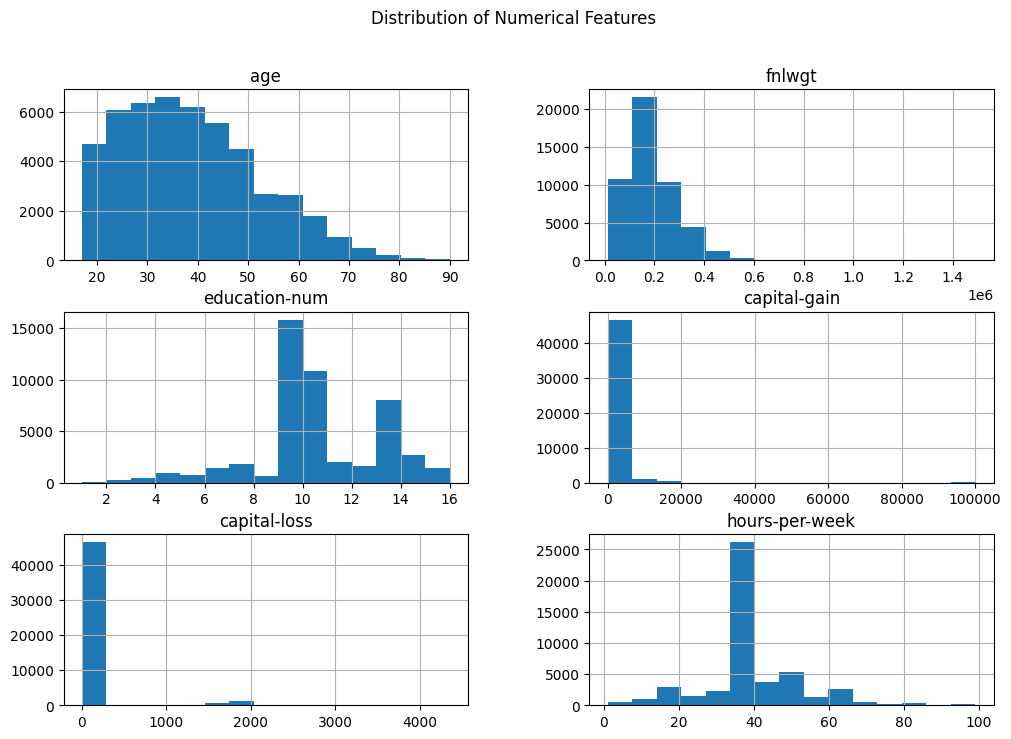

In [12]:
df.hist(bins=15, figsize=(12, 8))

plt.suptitle("Distribution of Numerical Features")
plt.show()

In [13]:
(df['income'].value_counts() / len(df)) * 100

,count
income,
<=50K,76.061705
>50K,23.938295


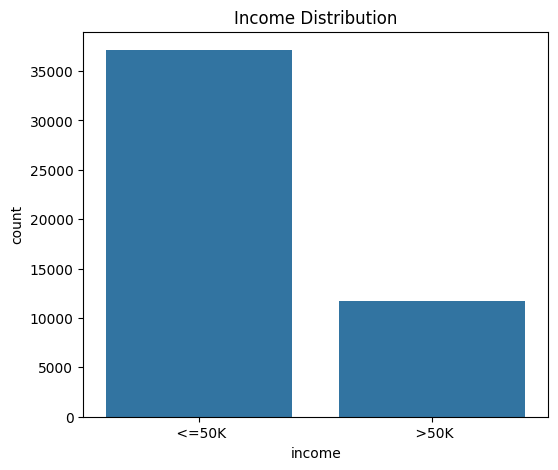

In [14]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='income')
plt.title("Income Distribution")
plt.show()

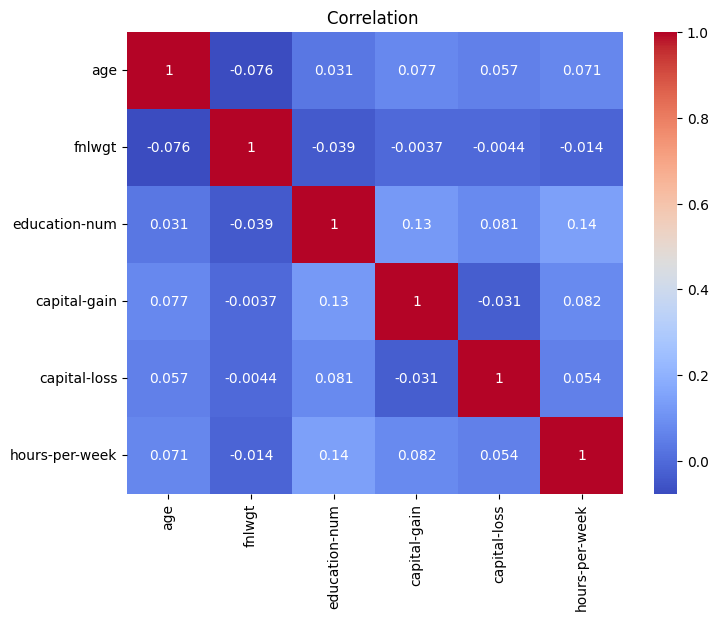

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation ")
plt.show()

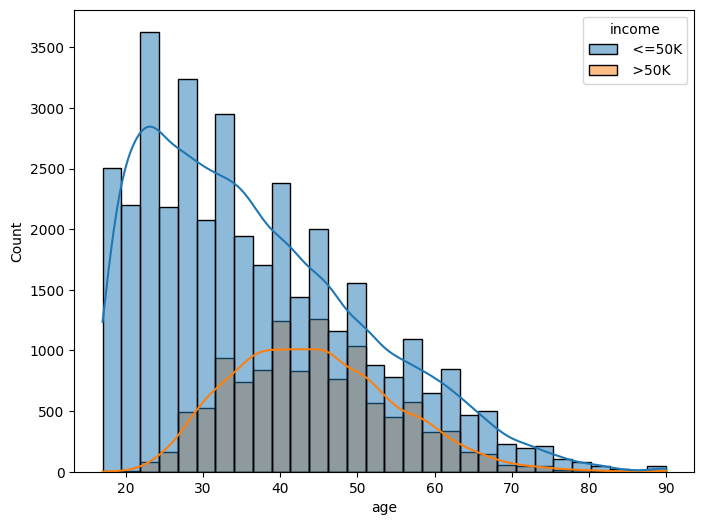

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'age', hue='income', bins=30, kde=True)
plt.show()

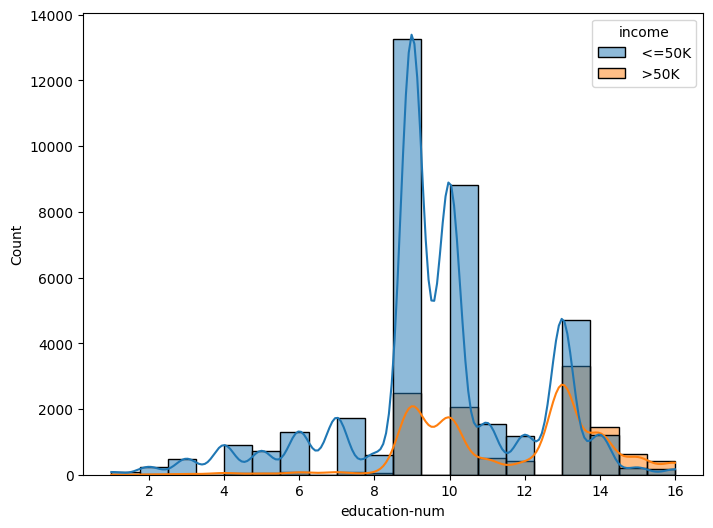

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'education-num', hue='income', bins=20, kde=True)
plt.show()

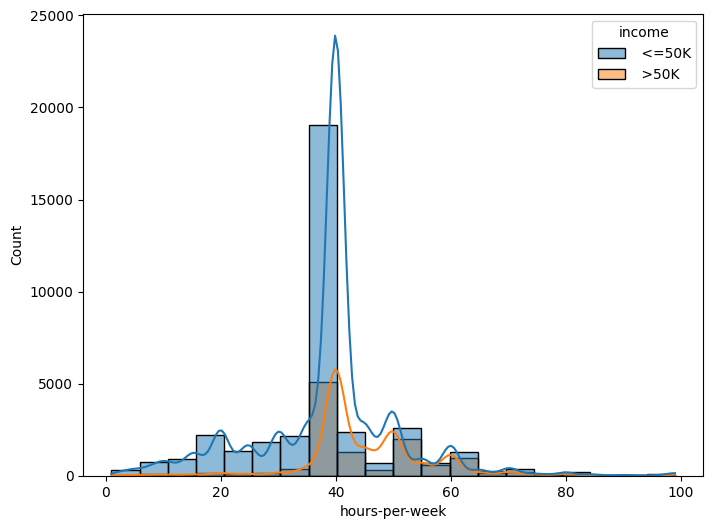

In [18]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x = 'hours-per-week', hue='income', bins=20, kde=True)
plt.show()

In [19]:
df['income'] = (df['income'].str.strip().str.replace('-', '', regex=False))

In [20]:
# statistical evidence

df['income_binary'] = (
    df['income'] == '>50K'
).astype(int)

feature = ['age', 'education-num', 'hours-per-week']

for col in feature:
  print(f"\n{col}")
  print("-"*30)
  print("Mean by Income")
  print(df.groupby('income')[col].mean().round(2))

  print("Correlation: ", round(df[col].corr(df['income_binary']), 3))


age
------------------------------
Mean by Income
income
<=50K    36.88
>50K     44.28
Name: age, dtype: float64
Correlation:  0.23

education-num
------------------------------
Mean by Income
income
<=50K     9.6
>50K     11.6
Name: education-num, dtype: float64
Correlation:  0.333

hours-per-week
------------------------------
Mean by Income
income
<=50K    38.84
>50K     45.45
Name: hours-per-week, dtype: float64
Correlation:  0.228


## **intuitively affects income**

---



**Education-num:** People with more education often qualify for the better-paying jobs, so their tends to be higher.

**Age:** Older individuals often have more experience and therefore earn higher salaries.

**Hours-per-week:** People who work more hours generally have greater responsibities and receive higher compensation.

---



## **3 features from most important to least important**

---

The top three factors are Education-Num, Age and Hours-per-week. Education-Num is the most important due to its strong impact on skills and job opportunities. Age comes second because experience increase earning potential and Hours-per-week comes third since longer working hours may lead to higher income but are not the sole determinant of earnings.

## **Question 2: Preprocessing Pipeline Design (Regression)**

In [21]:
X = df.drop(['hours-per-week'], axis=1)
y = df['hours-per-week']

In [22]:
# numerical features
numerical_features = X.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

# categorical features
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()


In [23]:
from sklearn import preprocessing
# numerical
numerical_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# numerical_pipeline

# categorical
categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)
# feature_pipeline


# columnTransform
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'income_binary']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country', 'income'])])

In [24]:
X_preprocessed = preprocessor.fit_transform(X)

print("Preprocessor Shape: ", X_preprocessed.shape)

Preprocessor Shape:  (48813, 107)


**For Numerical Features preprocessing applied:**

Missing values -> SimpleImputer(Strategy='Median')

Scaling -> StandardScaler()

**Why?**

=>Median is robust to outliers.

=>StandardScaler normalizes feature scales, helping regression algorithms perform better.


**For Categorical Features Preprocessing applied:**

Missing values -> SimpleImputer(strategy='most_frequent')

Encoding -> OneHotEncoder(handle_unknown-'ignore')

**why?**

=> Most frequent imputation preserves the most common category.

=> Regression models cannot work directly with text data, so OneHot Encoding converts categories into numerical binary features.

=> handle_unknown='ignore' prevents errors when new categories appear in test data.

## **Question 3: Regression Modeling & Evaluation**

In [25]:
# X, y define Question 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [26]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,native-country,income,income_binary
40819,70,NaN,210722,Prof-school,15,Divorced,NaN,Not-in-family,White,Male,2538,0,United-States,<=50K,0
40613,30,Private,195602,12th,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,United-States,<=50K,0
45445,59,Private,171242,Bachelors,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,United-States,<=50K,0
31318,22,Private,138504,Some-college,10,Never-married,Adm-clerical,Unmarried,Black,Female,0,0,United-States,<=50K,0
3719,21,Local-gov,596776,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,Guatemala,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11287,24,State-gov,247075,HS-grad,9,Never-married,Adm-clerical,Unmarried,Black,Female,0,0,United-States,<=50K,0
44759,52,Private,279440,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,United-States,>50K,1
38183,51,Self-emp-inc,77392,10th,6,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,United-States,>50K,1
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,United-States,<=50K,0


In [27]:
# Linear Regression Pipeline

lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'income_binary']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'income'])])),
                ('model', LinearRegression())])

In [28]:
lr_pred = lr_pipeline.predict(X_test)

In [29]:
# SGD Regressor
sgd_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'income_binary']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'income'])])),
                ('model', SGDRegressor())])

In [30]:
sgd_pred = sgd_pipeline.predict(X_test)

In [31]:
# Linear Reg
print("For Linear Regression")
print(f"R2: {round(r2_score(y_test, lr_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, lr_pred), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, lr_pred), 4)}")

print('-'*30)
# SGD Reg
print("For (SGD) Regressor")
print(f"R2: {round(r2_score(y_test, sgd_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, sgd_pred), 4)}")
print(f"MSE: {round(mean_squared_error(y_test, sgd_pred), 4)}")

For Linear Regression
R2: 0.1833
MAE: 7.7534
MSE: 124.7332
------------------------------
For (SGD) Regressor
R2: 0.1801
MAE: 7.8125
MSE: 125.2189


Linear Regression performed slightly better than the SGD Regressor because it achieved a marginally higher R2 score and lower MAE and MSE values. However, the difference are vary small, indicating that both models performed almost equally on this dataset

## **Question 4: Classification Pipeline & Error Analysis**

In [59]:
X = df.drop(['income', 'income_binary'], axis=1)
y = df['income']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42, stratify=y)

In [61]:
# numerical_features

num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# categorical_features
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

In [62]:
num_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [63]:
cat_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [64]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

In [65]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

In [66]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced' ,max_iter=1000, random_state=42))
    ]
)

In [67]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [68]:
y_pred = logistic_pipeline.predict(X_test)

In [69]:
print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred, pos_label='>50K'), 4)}")
print(f"Recall: {round(recall_score(y_test, y_pred, pos_label='>50K'), 4)}")

Accuracy: 0.807
Precision: 0.5652
Recall: 0.8404


In [70]:
lr_accuracy = round(accuracy_score(y_test, y_pred), 4)
lr_precision = round(precision_score(y_test, y_pred, pos_label='>50K'), 4)
lr_recall = round(recall_score(y_test, y_pred, pos_label='>50K'), 4)

## **Question 5: Hyperparameter Tuning & Model Comparison**

In [71]:
X = df.drop(['income', 'income_binary'], axis=1)
y = df['income']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42, stratify=y)

In [73]:
# numerical_features

num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# categorical_features
cat_features = X.select_dtypes(
    include=['object']
).columns.tolist()

In [74]:
num_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# cat
cat_pipeline = Pipeline(
    steps=[
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [75]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

In [76]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

In [77]:
# GridSearchCV
param_grid = {
    'model__n_neighbors' : range(3, 21, 2),
    'model__weights' : ['uniform', 'distance'],
    'model__metric' : ['euclidean', 'manhattan', 'minkowski']
}

In [78]:
grid_search = GridSearchCV(
    estimator = knn_pipeline,
    param_grid = param_grid,
    cv=5,
    scoring = 'accuracy',
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.82402049 0.81979513 0.83354673 0.82924456 0.83664533 0.83306018
 0.83795134 0.83485275 0.83948784 0.83628681 0.84056338 0.8384379
 0.8403073  0.83851472 0.84133163 0.83920615 0.84166453 0.83989757
        nan 0.81690141        nan 0.82658131        nan 0.83003841
        nan 0.83257362        nan 0.83564661        nan 0.83608195
        nan 0.83615877        nan 0.83820743        nan 0.83889885
 0.82402049 0.81979513 0.83354673 0.82924456 0.83664533 0.83306018
 0.83795134 0.83485275 0.83948784 0.83628681 0.84056338 0.8384379
 0.8403073  0.83851472 0.84133163 0.83920615 0.84166453 0.83989757]
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'fnlwgt',
                                                                          'education-num',
                                                                          'capital-gain',
                                                                          'capital-loss',
                                                                          'hours-per-week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impute',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('enco...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['workclass',
                                                                          'education',
                                                                          'marital-status',
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'sex',
                                                                          'native-country'])])),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__metric': ['euclidean', 'manhattan',
                                           'minkowski'],
                         'model__n_neighbors': range(3, 21, 2),
                         'model__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [79]:
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_, 4)

# Best KNN Prediction
best_knn = grid_search.best_estimator_
y_pred_knn = best_knn.predict(X_test)

Best Parameters:  {'model__metric': 'euclidean', 'model__n_neighbors': 19, 'model__weights': 'uniform'}
Best CV Score:  0.8416645326504482 4


In [80]:
knn_accuracy = round(accuracy_score(y_test, y_pred_knn), 4)
knn_precision = round(precision_score(y_test, y_pred_knn, pos_label='>50K'), 4)
knn_recall = round(recall_score(y_test, y_pred_knn, pos_label='>50K'), 4)

In [81]:
print(f"Accuracy: {knn_accuracy}")
print(f"Precision: {knn_precision}")
print(f"Recall: {knn_recall}")

Accuracy: 0.8478
Precision: 0.7069
Recall: 0.6222


In [82]:
comparison = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Tuned KNN'],
    'Accuracy' : [lr_accuracy, knn_accuracy],
    'Precision' : [lr_precision, knn_precision],
    'Recall' : [lr_recall, knn_recall]
})
print(comparison.round(4))

                 Model  Accuracy  Precision  Recall
0  Logistic Regression    0.8070     0.5652  0.8404
1            Tuned KNN    0.8478     0.7069  0.6222
